Notebook explaining step by step how we build the `compute_likelihood_map` function.

In [1]:
from retinotopy import *
args = Params()

HOST='obiwan.local'
Running on metal mps
On date 2024-04-25, Running learning on host obiwan.local with device mps
Welcome on macOS-14.4.1-arm64-arm-64bit


In [2]:
resolution = (128, 128)
resolution = (64, 64)
size_ratio = 0.3 # how much of the image to use relative to radius

## doing the computations

In [3]:
image_names = ['jaguar', 'jaguar_5', 'cheetah']
true_labels = ['jaguar', 'jaguar', 'cheetah']

In [4]:
for data_set_type in data_set_types:
    for model_name in  ['resnet101', 'resnet50', 'resnet18']:
        for do_polar in [True, False]:

            model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'
            if os.path.isfile(model_filename):
                print(f"Loading pre-trained resnet {model_filename}")
                model = charge_model(model_name=model_name, model_path=model_filename, 
                                    do_polar=args.do_polar).to(device).eval()

                for image_name, true_label in zip(image_names, true_labels):
                    map_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_map_{image_name}.npy'
                    if not os.path.isfile(map_filename):
                        image_url = f'./imgs/{image_name}.jpg'
                        full_image = read_image(image_url)/255
                        full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()

                        N_fixations = np.prod(resolution)
                        aspect_ratio = full_image.shape[1]/full_image.shape[2]
                        resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),
                                       int(np.sqrt(N_fixations/aspect_ratio)))

                        pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
                        args.image_size = box_size
                        args.do_polar = do_polar

                        pos_H, pos_W, outputs = compute_likelihood_map(args, model, full_image, resolution=resolution)
                        proba_label = outputs[:, i_labels_dico[true_label]].reshape(pos_H.shape)
                        np.save(map_filename, proba_label)
                    

Loading pre-trained resnet cached_data/2024-04-25_full_resnet101_do_polar=True.pt
loading .... cached_data/2024-04-25_full_resnet101_do_polar=True.pt
Loading pre-trained resnet cached_data/2024-04-25_full_resnet101_do_polar=False.pt
loading .... cached_data/2024-04-25_full_resnet101_do_polar=False.pt
Loading pre-trained resnet cached_data/2024-04-25_full_resnet50_do_polar=True.pt
loading .... cached_data/2024-04-25_full_resnet50_do_polar=True.pt
Loading pre-trained resnet cached_data/2024-04-25_full_resnet50_do_polar=False.pt
loading .... cached_data/2024-04-25_full_resnet50_do_polar=False.pt
Loading pre-trained resnet cached_data/2024-04-25_full_resnet18_do_polar=True.pt
loading .... cached_data/2024-04-25_full_resnet18_do_polar=True.pt
Loading pre-trained resnet cached_data/2024-04-25_full_resnet18_do_polar=False.pt
loading .... cached_data/2024-04-25_full_resnet18_do_polar=False.pt
Loading pre-trained resnet cached_data/2024-04-25_focus_resnet101_do_polar=True.pt
loading .... cached

## doing the figure

/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_24888/834472048.py:21: UserWarning: linewidths is ignored by contourf
  axs[i_image, i_polar+1].contourf(pos_W, pos_H, proba_label, levels=np.linspace(0, proba_max, 10), cmap=mycmap, vmin=0, vmax=proba_max, linewidths=3)


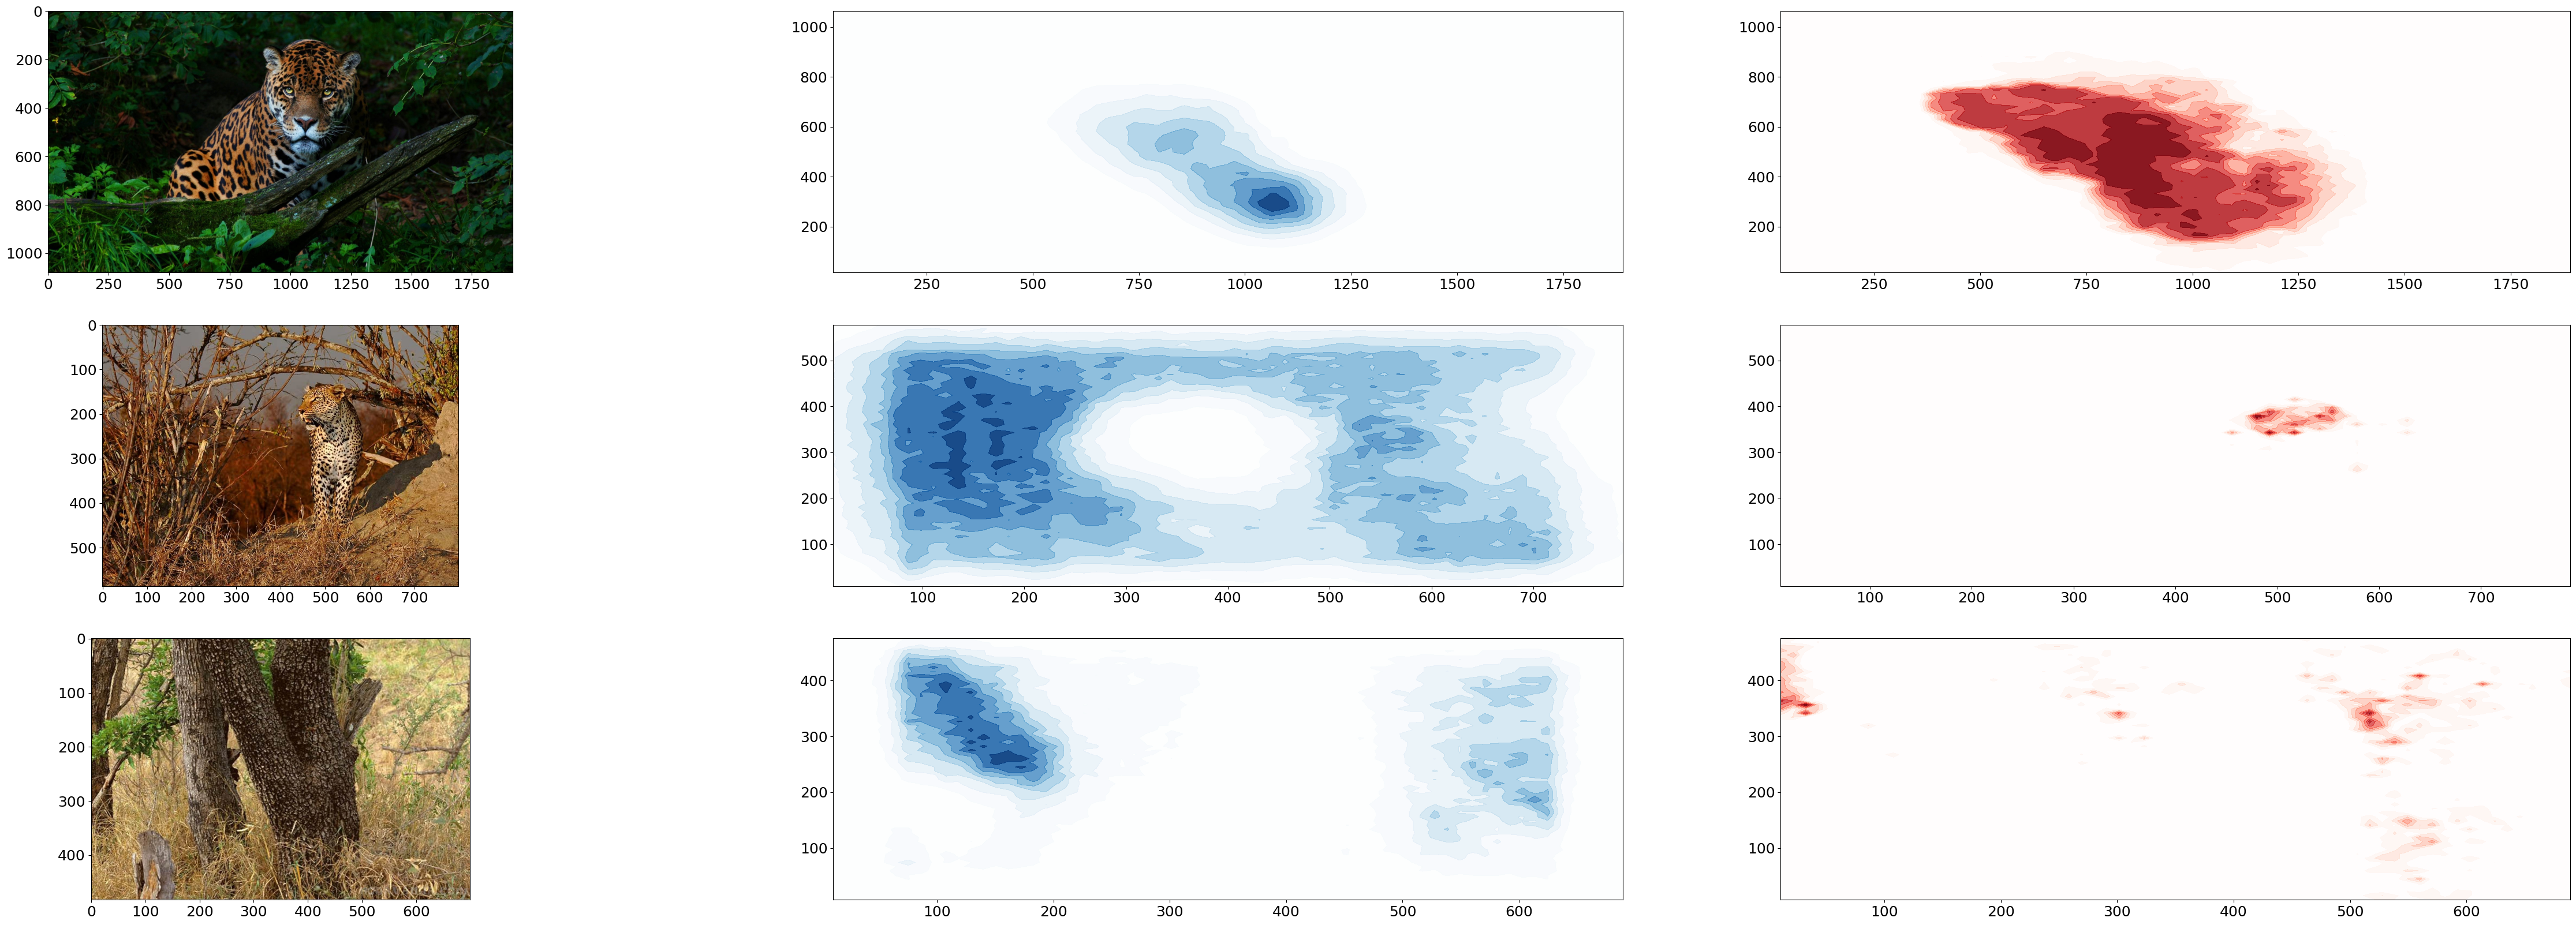

In [10]:
data_set_type = 'focus'
model_name = 'resnet101'

fig, axs = plt.subplots(len(image_names), 3, figsize=(fig_width*len(image_names), fig_width))
for i_image, (image_name, true_label) in enumerate(zip(image_names, true_labels)):

    image_url = f'./imgs/{image_name}.jpg'
    full_image = read_image(image_url)/255
    full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()

    axs[i_image, 0].imshow(full_image_np)

    # ax.set_xticks([])
    pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
    resolution = pos_H.shape
    for i_polar, do_polar in enumerate([False, True]):
        map_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_map_{image_name}.npy'
        proba_label = np.load(map_filename)
        proba_max = 1.
        proba_max = proba_label.max()
        mycmap = transparent_cmap(plt.cm.Reds if do_polar else plt.cm.Blues)
        axs[i_image, i_polar+1].contourf(pos_W, pos_H, proba_label, levels=np.linspace(0, proba_max, 10), cmap=mycmap, vmin=0, vmax=proba_max, linewidths=3)
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [6]:
pos_H.shape

(64, 64)

In [7]:
for ext in exts:
    fig.savefig(f'figs/fig-likelihood_map.{ext}',  **opts_savefig)